# Regime Detection in U.S. Equity and Credit Markets
## 3-State Gaussian Hidden Markov Model

COMP 490


In [1]:
# imports and setup

!pip install -q yfinance fredapi hmmlearn

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")
LABELS = ["Calm", "Transition", "Crisis"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.8 MB/s eta 0:00:00


In [2]:
# fred API key set up, uses colab's secret key manager, needs to bwe entered when prompted.

key = None
try:
    from google.colab import userdata
    try:
        key = userdata.get("FRED_API_KEY")
    except Exception:
        print("No Colab secret found; using prompt instead.")
except ImportError:
    pass

if not key:
    import getpass
    key = getpass.getpass("FRED API key: ")

key = key.strip()
assert re.fullmatch(r"[a-z0-9]{32}", key), f"Not a valid FRED key: {key[:20]!r}"
os.environ["FRED_API_KEY"] = key
print("Key set.")

No Colab secret found; using prompt instead.
FRED API key: ··········
Key set.


In [3]:
# dataset sourcing function  S&P from yahoo finance and high-yield and investment-grade from FRED.
# NOTE: two sources have different calendards, timezone-aware (yfinance) vs not the case for fredapi, function normalizeds before joining
# OAS series are forward-filled and prices are not (left as undefined)

# ""OAS is a level: a missing day still had a value, so carry the last one forward.
# A return is a change: on a non-trading day there is no return to impute,
# so those rows are dropped rather than filled (ffilling price fabricates a 0%).""

START = "2005-01-01"

def fetch_data(start=START):
    import yfinance as yf
    from fredapi import Fred

    px = yf.download("^GSPC", start=start, progress=False, auto_adjust=True)
    if isinstance(px.columns, pd.MultiIndex):
        px.columns = px.columns.get_level_values(0)
    px = px[["Close", "Volume"]]
    px.columns = ["close", "volume"]
    px.index = pd.DatetimeIndex(px.index).tz_localize(None).normalize()

    fred = Fred(api_key=os.environ["FRED_API_KEY"])
    cr = pd.DataFrame({
        "hy_oas": fred.get_series("BAMLH0A0HYM2", observation_start=start),
        "ig_oas": fred.get_series("BAMLC0A0CM",   observation_start=start)})
    cr.index = pd.DatetimeIndex(cr.index).tz_localize(None).normalize()

    df = px.join(cr.reindex(px.index.union(cr.index)).ffill(), how="left")
    df = df.dropna(subset=["close"]).ffill().dropna()

    print(f"S&P from {px.index.min().date()}, "
          f"HY from {cr['hy_oas'].first_valid_index().date()}, "
          f"IG from {cr['ig_oas'].first_valid_index().date()}")
    print(f"Aligned: {len(df)} rows, {df.index.min().date()} -> "
          f"{df.index.max().date()} (~{len(df)/252:.1f} years)")
    return df

data = fetch_data()
data.head()

S&P from 2005-01-03, HY from 2023-07-24, IG from 2023-07-24
Aligned: 752 rows, 2023-07-24 -> 2026-07-22 (~3.0 years)


,close,volume,hy_oas,ig_oas
Date,,,,
2023-07-24,4554.640137,3856250000,3.82,1.25
2023-07-25,4567.459961,3812470000,3.84,1.24
2023-07-26,4566.750000,3990290000,3.91,1.23
2023-07-27,4537.410156,4553210000,3.78,1.20
2023-07-28,4582.229980,3981010000,3.82,1.19


In [4]:
# preprocessing and feature engineering , needed fo the model to use pertinent information of each feature, i.e. stationary, turbulence, credit stress isolation

# Log return: price level -> stationary daily change.
# Logs make returns additive over time and roughly symmetric up vs down.

# Realized volatility: rolling std of returns = how turbulent the last month was.
# sqrt(252) rescales daily to annual, the convention for quoting vol.

# Credit stress: HY minus IG isolates compensation for DEFAULT risk.
# The difference cancels the common move both grades share with rates.

# dropna(): drops the first VOL_WINDOW rows, where diff() and rolling()
# have no history yet.

VOL_WINDOW = 21

features = pd.DataFrame(index=data.index)
features["log_return"]    = np.log(data["close"]).diff()
features["realized_vol"]  = features["log_return"].rolling(VOL_WINDOW).std() * np.sqrt(252)
features["credit_stress"] = data["hy_oas"] - data["ig_oas"]
features = features.dropna()

print(f"{len(features)} rows, {features.index.min().date()} -> "
      f"{features.index.max().date()}")
features.describe().T.round(4)

731 rows, 2023-08-22 -> 2026-07-22


,count,mean,std,min,25%,50%,75%,max
log_return,731.0,0.0007,0.0095,-0.0616,-0.0034,0.0011,0.0058,0.0909
realized_vol,731.0,0.1360,0.0677,0.0542,0.1023,0.1226,0.1446,0.4928
credit_stress,731.0,2.2521,0.2978,1.7800,2.0400,2.2000,2.3550,3.4100


In [5]:
# methodes, model fitting
# Gaussian HMM assuming unobserved states {1,2,3}
# parameter estimation ;: EM(Baum-Welch) converging to a local critical point , repeeted for several random initializatonis and highest-likelihood model kept
# state indices are arbitrary : labeld after fitting by ranking their mean realized volatility: lowest is Calm, highest is Crisis.

def fit_hmm(X, n_states=3, n_restarts=15, cov="diag", seed=42):
    """Fit on already-standardized X, keeping the best of several restarts."""
    rng = np.random.RandomState(seed)
    best, best_ll = None, -np.inf
    for _ in range(n_restarts):
        m = GaussianHMM(n_components=n_states, covariance_type=cov,
                        n_iter=1000, tol=1e-4, random_state=rng.randint(10**6))
        try:
            m.fit(X)
            ll = m.score(X)
            if np.isfinite(ll) and ll > best_ll:
                best, best_ll = m, ll
        except Exception:
            continue
    if best is None:
        raise RuntimeError("All EM restarts failed.")
    return best, best_ll


COV, N_RESTARTS = "diag", 15
vol_idx = list(features.columns).index("realized_vol")

scaler = StandardScaler().fit(features.values)
X = scaler.transform(features.values)

model, ll = fit_hmm(X, n_restarts=N_RESTARTS, cov=COV)
order = np.argsort(model.means_[:, vol_idx])     # ascending vol -> Calm..Crisis

print(f"Log-likelihood: {ll:.1f}")
print("Raw state -> label:", {int(order[i]): LABELS[i] for i in range(3)})

Log-likelihood: -2105.4
Raw state -> label: {0: 'Calm', 2: 'Transition', 1: 'Crisis'}


In [6]:
# experiment set up and fitted model summary
# diagnostics allow to watchout for low-self persistance (self loops) and states that are practically unreachable.


# TABLE 1 -emission parameters, converted back to original units
means = pd.DataFrame(scaler.inverse_transform(model.means_[order]),
                     index=LABELS, columns=features.columns)
print("TABLE 1 - Emission means (original units)")
display(means.round(4))

# TABLE 2 - transition matrix and implied durations
A = model.transmat_[np.ix_(order, order)]
trans = pd.DataFrame(A, index=LABELS, columns=LABELS)
trans["exp_duration_days"] = 1 / (1 - np.diag(A))
print("\nTABLE 2 - Transition matrix and expected durations")
display(trans.round(4))

print("\nDIAGNOSTICS")
for i, lab in enumerate(LABELS):
    inflow = A[:, i].sum() - A[i, i]
    flag = ""
    if A[i, i] < 0.5:   flag += "  <-- not persistent"
    if inflow < 1e-3:   flag += "  <-- UNREACHABLE (degenerate)"
    print(f"  {lab:11s} self={A[i,i]:.4f}  inflow={inflow:.4f}{flag}")

TABLE 1 - Emission means (original units)


,log_return,realized_vol,credit_stress
Calm,0.0006,0.1159,2.0936
Transition,0.0011,0.1444,2.5124
Crisis,-0.0000,0.4408,2.8810



TABLE 2 - Transition matrix and expected durations


,Calm,Transition,Crisis,exp_duration_days
Calm,0.9917,0.0083,0.0000,120.5421
Transition,0.0215,0.9741,0.0044,38.6204
Crisis,0.0000,0.0400,0.9600,25.0123



DIAGNOSTICS
  Calm        self=0.9917  inflow=0.0215
  Transition  self=0.9741  inflow=0.0483
  Crisis      self=0.9600  inflow=0.0044


## 4. Results and visualizations

### Descriptive regime history

Viterbi decoding on the full sample gives the most likely regime sequence, and
the smoothed posterior gives the probability of each regime at each date. Both
condition on the entire sample, so they describe history rather than forecast;
the forecasts evaluated in Section 5 use only past data.

Regime occupancy (Viterbi):
Calm          0.6621
Transition    0.3037
Crisis        0.0342


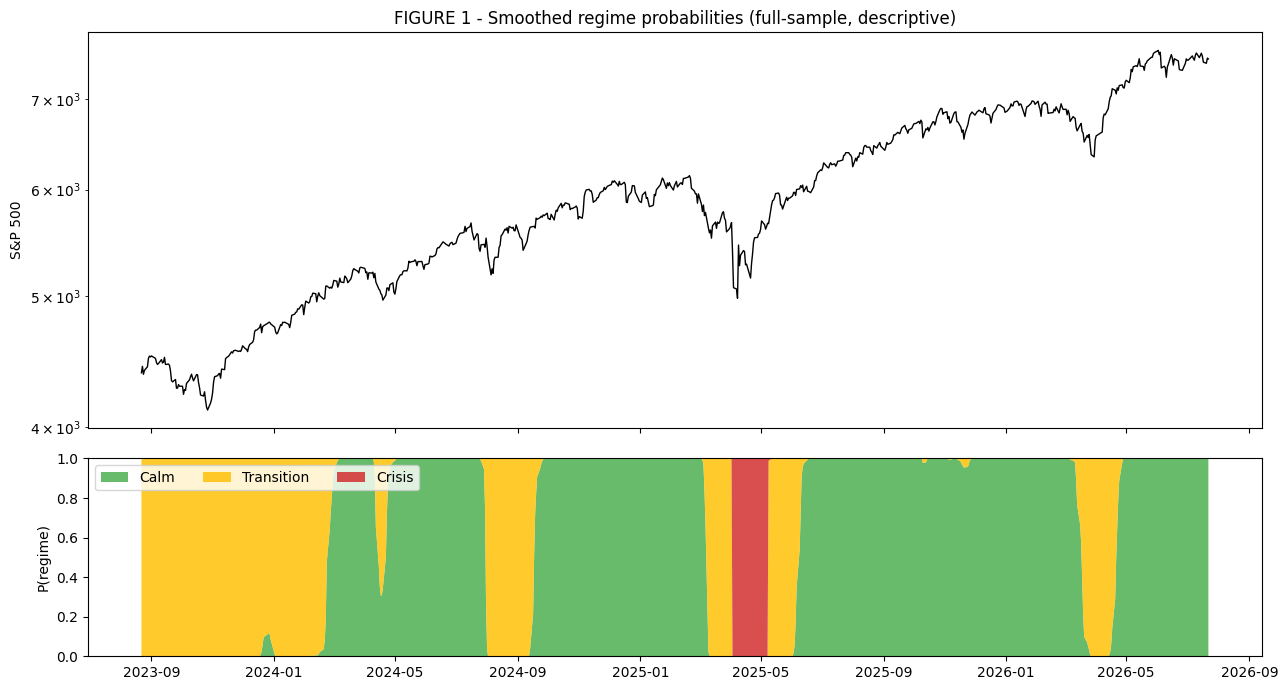

In [7]:
viterbi  = pd.Series(np.argsort(order)[model.predict(X)], index=features.index)
smoothed = pd.DataFrame(model.predict_proba(X)[:, order],
                        columns=LABELS, index=features.index)

print("Regime occupancy (Viterbi):")
print((viterbi.value_counts(normalize=True).sort_index()
       .rename(dict(enumerate(LABELS))).round(4)).to_string())

colors = ["#4CAF50", "#FFC107", "#D32F2F"]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a1.plot(data["close"].loc[features.index], color="black", lw=1)
a1.set_yscale("log"); a1.set_ylabel("S&P 500")
a1.set_title("FIGURE 1 - Smoothed regime probabilities (full-sample, descriptive)")
a2.stackplot(smoothed.index, [smoothed[c] for c in LABELS],
             labels=LABELS, colors=colors, alpha=0.85)
a2.set_ylim(0, 1); a2.set_ylabel("P(regime)"); a2.legend(loc="upper left", ncol=3)
plt.tight_layout(); plt.show()

### Forward forecast

The predictive distribution is obtained by propagating the current filtered
state through the transition matrix, $\pi_{t+h} = \pi_t A^h$. This needs no
future observations, which is what makes it a forecast rather than a smoothed
in-sample estimate.

Filtered state on 2026-07-22: {'Calm': np.float64(1.0), 'Transition': np.float64(0.0), 'Crisis': np.float64(0.0)}


,Calm,Transition,Crisis
1,0.991,0.009,0.000
2,0.983,0.017,0.000
3,0.976,0.024,0.000
4,0.968,0.032,0.000
5,0.961,0.039,0.000
6,0.954,0.046,0.000
7,0.947,0.053,0.001
8,0.940,0.059,0.001
9,0.933,0.066,0.001
10,0.927,0.072,0.001


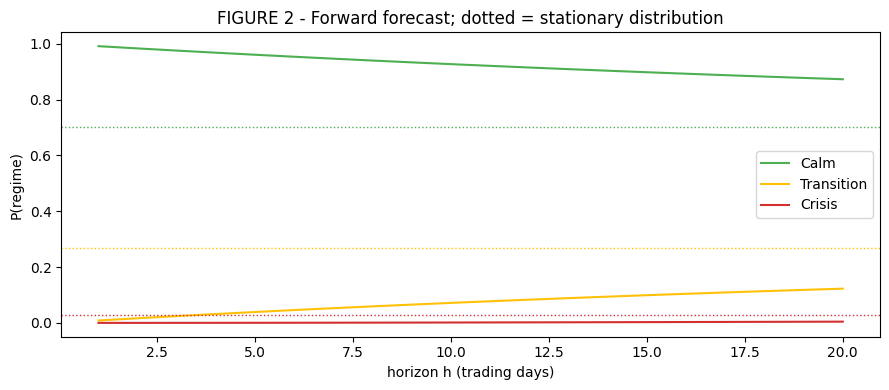

In [8]:
def forward_filter(model, X):
    """Causal filtered posteriors P(S_t | x_1..x_t). Row t uses no data after t."""
    lp = np.column_stack([
        multivariate_normal.logpdf(X, model.means_[i], model.covars_[i],
                                   allow_singular=True)
        for i in range(model.n_components)])
    alpha = np.empty_like(lp)
    p = np.log(model.startprob_ + 1e-12) + lp[0]
    alpha[0] = np.exp(p - p.max()); alpha[0] /= alpha[0].sum()
    for t in range(1, len(lp)):
        p = np.log(alpha[t-1] @ model.transmat_ + 1e-12) + lp[t]
        alpha[t] = np.exp(p - p.max()); alpha[t] /= alpha[t].sum()
    return alpha


alpha = forward_filter(model, X)
assert np.allclose(forward_filter(model, X[:500]), alpha[:500], atol=1e-9)

pi, rows = alpha[-1], []
for _ in range(20):
    pi = pi @ model.transmat_
    rows.append(pi[order])
fc = pd.DataFrame(rows, index=range(1, 21), columns=LABELS)

print(f"Filtered state on {features.index[-1].date()}: "
      f"{dict(zip(LABELS, alpha[-1][order].round(3)))}")
display(fc.head(10).round(3))

ax = fc.plot(figsize=(9, 4), color=colors)
for v, c in zip(np.linalg.matrix_power(model.transmat_, 5000)[0][order], colors):
    ax.axhline(v, ls=":", lw=1, color=c)
ax.set_xlabel("horizon h (trading days)"); ax.set_ylabel("P(regime)")
ax.set_title("FIGURE 2 - Forward forecast; dotted = stationary distribution")
plt.tight_layout(); plt.show()

Summary

In [12]:
print(f"Sample      : {features.index[0].date()} -> {features.index[-1].date()} "
      f"({len(features)} obs, ~{len(features)/252:.1f}y)")
print(f"Model       : 3-state Gaussian HMM, {COV} covariance, "
      f"{N_RESTARTS} EM restarts, logL={ll:.1f}")
print(f"Walk-forward: burn-in {BURN_IN}, refit every {REFIT_EVERY}, "
      f"{len(wf)} one-step forecasts")
print("\nRegime occupancy (Viterbi):")
print(viterbi.value_counts(normalize=True).sort_index()
      .rename(dict(enumerate(LABELS))).round(4).to_string())
print("\nExpected durations (days):")
print(trans["exp_duration_days"].round(1).to_string())

Sample      : 2023-08-22 -> 2026-07-22 (731 obs, ~2.9y)
Model       : 3-state Gaussian HMM, diag covariance, 15 EM restarts, logL=-2105.4
Walk-forward: burn-in 250, refit every 21, 480 one-step forecasts

Regime occupancy (Viterbi):
Calm          0.6621
Transition    0.3037
Crisis        0.0342

Expected durations (days):
Calm          120.5
Transition     38.6
Crisis         25.0
